In [5]:
import pandas as pd
import matplotlib.pyplot as plt

#importing data
books = pd.read_csv('book.csv')

In [6]:
# one hot encoding
books_onehot = pd.get_dummies(books, prefix='', prefix_sep='')


In [7]:
# Apply Apriori algorithm
from mlxtend.frequent_patterns import apriori, association_rules
frequent_itemsets = apriori(books_onehot, min_support=0.05, use_colnames=True)

/usr/local/lib/python3.10/dist-packages/mlxtend/frequent_patterns/fpcommon.py:110: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [8]:
# Generate and filter association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
rules_filtered = rules[(rules['antecedents'].apply(len) >= 2) & (rules['consequents'].apply(len) >= 2)]
rules
len(rules_filtered)
rules_filtered

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
128,"(YouthBks, CookBks)","(ChildBks, DoItYBks)",0.1620,0.1840,0.0820,0.506173,2.750939,0.052192,1.652400,0.759532
129,"(YouthBks, DoItYBks)","(ChildBks, CookBks)",0.1155,0.2560,0.0820,0.709957,2.773268,0.052432,2.565134,0.722911
134,"(YouthBks, RefBks)","(ChildBks, CookBks)",0.0965,0.2560,0.0680,0.704663,2.752591,0.043296,2.519158,0.704710
139,"(YouthBks, ArtBks)","(ChildBks, CookBks)",0.1010,0.2560,0.0670,0.663366,2.591275,0.041144,2.210118,0.683081
144,"(ChildBks, YouthBks)","(CookBks, GeogBks)",0.1650,0.1925,0.0830,0.503030,2.613144,0.051238,1.624848,0.739305
145,"(YouthBks, CookBks)","(ChildBks, GeogBks)",0.1620,0.1950,0.0830,0.512346,2.627414,0.051410,1.650759,0.739138
146,"(YouthBks, GeogBks)","(ChildBks, CookBks)",0.1205,0.2560,0.0830,0.688797,2.690612,0.052152,2.390720,0.714426
151,"(YouthBks, RefBks)","(ChildBks, DoItYBks)",0.0965,0.1840,0.0530,0.549223,2.984907,0.035244,1.810207,0.736006
152,"(RefBks, DoItYBks)","(ChildBks, YouthBks)",0.1055,0.1650,0.0530,0.502370,3.044665,0.035592,1.677952,0.750762
157,"(YouthBks, ArtBks)","(ChildBks, DoItYBks)",0.1010,0.1840,0.0510,0.504950,2.744296,0.032416,1.648320,0.707017


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
/usr/local/lib/python3.10/dist-packages/pandas/core/dtypes/cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])


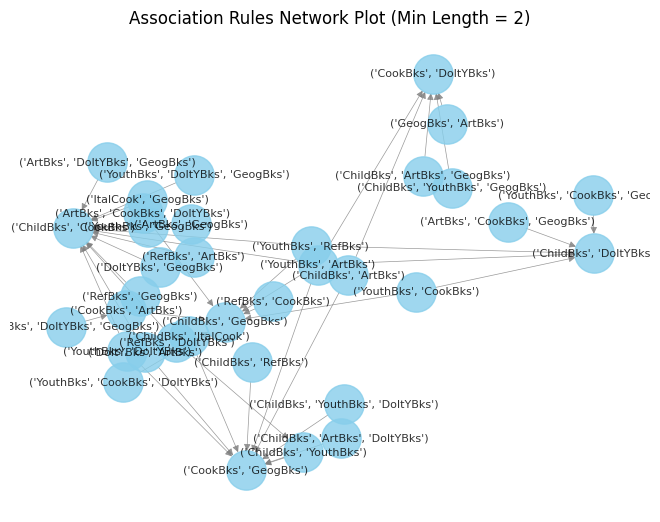

In [9]:
# Network Plot
import networkx as nx
G = nx.DiGraph()
for i, row in rules_filtered.iterrows():
    G.add_edge(tuple(row['antecedents']), tuple(row['consequents']), weight=row['support'])

pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, font_size=8, font_color='black', node_size=800, node_color='skyblue', edge_color='gray', width=0.5, alpha=0.8, arrowsize=10)
plt.title('Association Rules Network Plot (Min Length = 2)')
plt.show()